   Unnamed: 0 ccode  year    education_level age_group  gender  \
0        1980   CIV  2015  Less than primary     15-24  female   
1        1981   CIV  2016  Less than primary     15-24  female   
2        1982   CIV  2017  Less than primary     15-24  female   
3        1983   CIV  2018  Less than primary     15-24  female   
4        1984   CIV  2019  Less than primary     15-24  female   

   unemployment_rate  inactivity_rate  
0           0.022517         0.408283  
1           0.010740         0.454940  
2           0.033620         0.622550  
3           0.032850         0.547630  
4           0.032080         0.472710  
    year  vulnerability
0   2015       0.822119
1   2016       0.829923
2   2017       0.836210
3   2018       0.790172
4   2019       0.744134
5   2020       0.772809
6   2021       0.801484
7   2022       0.830160
8   2023       0.830160
9   2024       0.830160
10  2025       0.830160
MAE : 0.01684322640442295


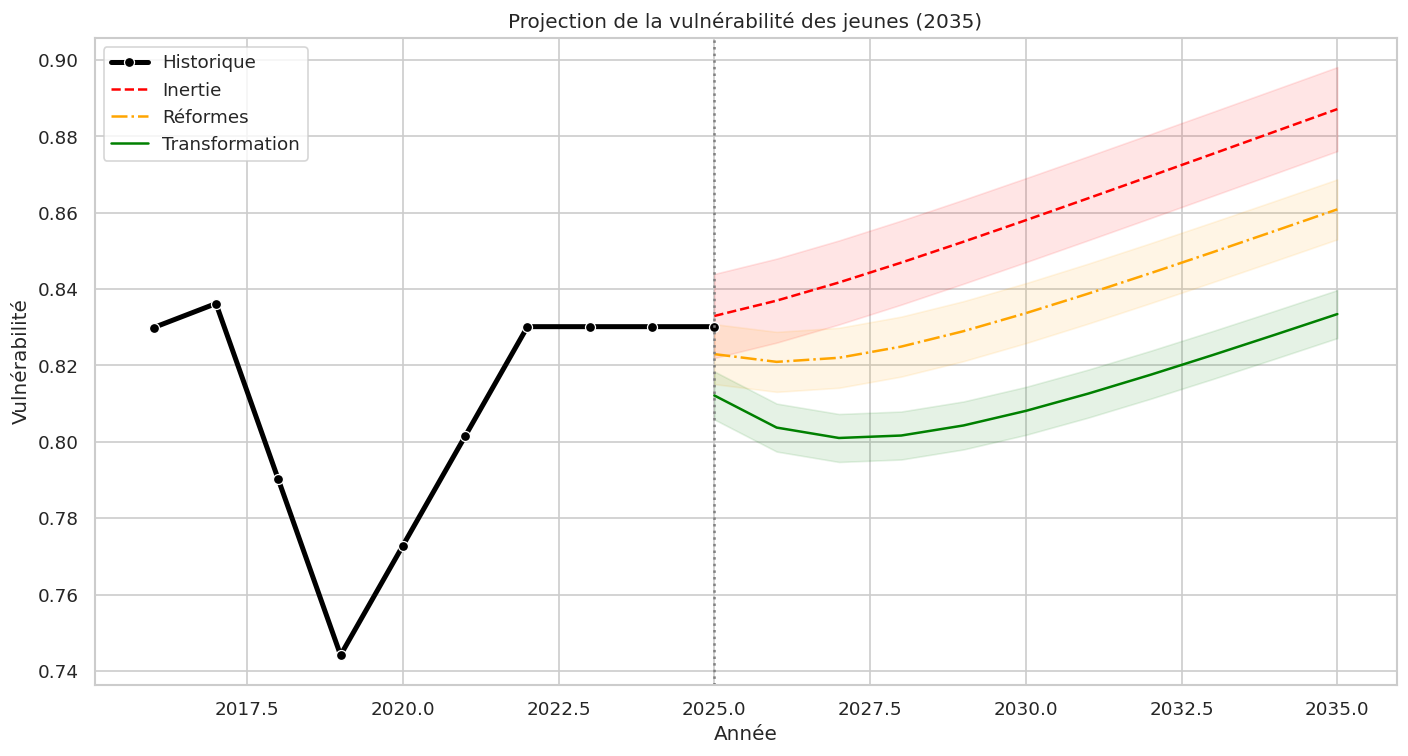

         Scénario    2035
0         Inertie  88.71%
1        Réformes  86.09%
2  Transformation  83.35%

- L'inertie maintient une vulnérabilité élevée.
- Les réformes réduisent progressivement la vulnérabilité.
- La transformation structurelle produit la plus forte baisse.



In [6]:
# ==========================================================
# 1. IMPORTS
# ==========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

sns.set_theme(style="whitegrid")


# ==========================================================
# 2. CHARGEMENT DES DONNÉES
# ==========================================================

path_processed = os.path.join('..', 'data', 'processed')
file_path = os.path.join(path_processed, 'ci_education_unemployed')

_df = pd.read_csv(file_path)

# Nettoyage colonnes
_df.columns = _df.columns.str.strip()

print(_df.head())


# ==========================================================
# 3. INDICATEUR DE VULNÉRABILITÉ
# ==========================================================

_df['vulnerability'] = _df['unemployment_rate'] + _df['inactivity_rate']

trend = (
    _df
    .groupby('year')['vulnerability']
    .mean()
    .reset_index()
    .sort_values('year')
)

trend['year'] = trend['year'].astype(int)

print(trend)


# ==========================================================
# 4. FEATURE ENGINEERING
# ==========================================================

trend['lag_1'] = trend['vulnerability'].shift(1)
trend = trend.dropna().reset_index(drop=True)

X = trend[['year', 'lag_1']]
y = trend['vulnerability']


# ==========================================================
# 5. MODÈLE
# ==========================================================

model = LinearRegression()
model.fit(X, y)

pred = model.predict(X)

mae = mean_absolute_error(y, pred)
print("MAE :", mae)


# ==========================================================
# 6. PROJECTIONS 2025–2035
# ==========================================================

future_years = list(range(2025, 2036))
last_value = trend['vulnerability'].iloc[-1]


# --------------------------
# SCÉNARIO 1
# --------------------------

scenario_1 = []
current = last_value

for year in future_years:
    X_future = pd.DataFrame({
        'year': [year],
        'lag_1': [current]
    })

    pred = model.predict(X_future)[0]
    scenario_1.append(pred)
    current = pred


# --------------------------
# SCÉNARIO 2
# --------------------------

scenario_2 = []
current = last_value

for year in future_years:
    X_future = pd.DataFrame({
        'year': [year],
        'lag_1': [current]
    })

    pred = model.predict(X_future)[0] * 0.988
    scenario_2.append(pred)
    current = pred


# --------------------------
# SCÉNARIO 3
# --------------------------

scenario_3 = []
current = last_value

for year in future_years:
    X_future = pd.DataFrame({
        'year': [year],
        'lag_1': [current]
    })

    pred = model.predict(X_future)[0] * 0.975
    scenario_3.append(pred)
    current = pred


# ==========================================================
# 7. VISUALISATION
# ==========================================================

std_dev = trend['vulnerability'].std()

upper_1 = np.array(scenario_1) + std_dev * 0.35
lower_1 = np.array(scenario_1) - std_dev * 0.35

upper_2 = np.array(scenario_2) + std_dev * 0.25
lower_2 = np.array(scenario_2) - std_dev * 0.25

upper_3 = np.array(scenario_3) + std_dev * 0.20
lower_3 = np.array(scenario_3) - std_dev * 0.20


fig, ax = plt.subplots()

sns.lineplot(
    data=trend,
    x='year',
    y='vulnerability',
    marker='o',
    linewidth=3,
    color='black',
    label='Historique',
    ax=ax
)

ax.plot(future_years, scenario_1, '--', color='red', label='Inertie')
ax.fill_between(future_years, lower_1, upper_1, alpha=0.1, color='red')

ax.plot(future_years, scenario_2, '-.', color='orange', label='Réformes')
ax.fill_between(future_years, lower_2, upper_2, alpha=0.1, color='orange')

ax.plot(future_years, scenario_3, '-', color='green', label='Transformation')
ax.fill_between(future_years, lower_3, upper_3, alpha=0.1, color='green')

ax.axvline(2025, linestyle=':', color='gray')

ax.set_title("Projection de la vulnérabilité des jeunes (2035)")
ax.set_xlabel("Année")
ax.set_ylabel("Vulnérabilité")

plt.legend()
plt.show()


# ==========================================================
# 8. TABLEAU RÉCAPITULATIF
# ==========================================================

summary = pd.DataFrame({
    "Scénario": ["Inertie", "Réformes", "Transformation"],
    "2035": [
        f"{scenario_1[-1]:.2%}",
        f"{scenario_2[-1]:.2%}",
        f"{scenario_3[-1]:.2%}"
    ]
})

print(summary)


# ==========================================================
# 9. INTERPRÉTATION
# ==========================================================

print("""
- L'inertie maintient une vulnérabilité élevée.
- Les réformes réduisent progressivement la vulnérabilité.
- La transformation structurelle produit la plus forte baisse.
""")

In [4]:
print(_df.columns)

Index(['Unnamed: 0', 'ccode', 'year', 'education_level', 'age_group', 'gender',
       'unemployment_rate', 'inactivity_rate'],
      dtype='str')
